In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.append(r"../main_code/2d")
import generate_data,mesh,adaptive_int,visual,matrix_assemble,inverse_solver,mea_2d,net_2d,source_eval,error_general_2d,main
import matplotlib.pyplot as plt
CUDA_LAUNCH_BLOCKING=1

def kidney_curve(x, y, h, k, a):
    """
    Compute the implicit kidney-curve value at the given point (x, y).
    
    Parameters:
    x, y: Input coordinate points.
    h, k: Coordinates of the kidney-curve center used for translation.
    a:    Size parameter of the kidney curve.
    """
    x_shifted = x - h
    y_shifted = y - k
    
    # Avoid issues when a = 0.
    if a == 0:
        a = 1e-9

    # Implicit kidney-curve equation: (x_sh^2 + y_sh^2 - 4a^2)^3 - 108a^4 * y_sh^2 = 0
    term1 = (x_shifted**2 + y_shifted**2 - 4 * a**2)**3
    term2 = 108 * a**4 * y_shifted**2
    return term1 - term2

def Gauss_source(X,x_left,x_right,y_below,y_upper,center,r):
    # 1. Primary Gaussian source (simulated tumor).
    x=X[:,0]
    y=X[:,1]
    src1 = 1.2 * np.exp(-((x-0.3)**2 + (y-0.6)**2)/0.008)
    return src1

def kidney_source(X,x_left,x_right,y_below,y_upper,center,r,h=0.6, k=0.25, s=0.05):
    """Kidney-shaped source function."""
    x = X[:, 0]
    y = X[:, 1]
    # Kidney-shaped source with translation and scaling.
    kidney_src = np.where(kidney_curve(x, y, h, k, s) <= 0, 1.0, 0.0)
    return kidney_src

def elegant_source(X,x_left,x_right,y_below,y_upper,center,r,h=0.6, k=0.25, s=0.05):
    """Improved complex source function."""
    gauss= Gauss_source(X,x_left,x_right,y_below,y_upper,center,r)
    # Kidney-shaped source with translation and scaling.
    kidney_src = kidney_source(X, x_left, x_right, y_below, y_upper, center, r, h, k, s)

    return kidney_src +gauss




cuda:3


In [2]:
import copy
np.random.seed(2)
torch.manual_seed(2)
torch.cuda.manual_seed_all(2) # Fix the random seed
Nx,Ny=1,1
Ix,Iy=4,4  # Number of grid cells in the x direction
nx,ny=3,3  # Gauss points per cell in the x direction
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89,93,97,101] # Grid-point indices
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max=-0.5,1.5,-0.5,1.5 # On boundary Gamma

num_batches_gauss=1
b_n=20
points_b=mea_2d.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) # Collect data on boundary Gamma
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.2
center_true=np.array([0.6,0.25])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device = device.index if device.type == "cuda" else 0
number=120
a=0.05
S_int_true,F_mea_b,F_mea_db_x1,F_mea_db_x2=generate_data.boundary_data_circle(kk,120,points_b,kidney_source,0,1,0,1,center_true,1,a,eps,mea,batch_number_rec_mea,device,cupy_device)
S_int_true_g,F_mea_b_g,F_mea_db_x1_g,F_mea_db_x2_g=generate_data.boundary_data_rec(kk,120,points_b,Gauss_source,0,1,0,1,center_true,1,eps,mea,batch_number_rec_mea,device,cupy_device)
F=inverse_solver.F(F_mea_b+F_mea_b_g,F_mea_db_x1+F_mea_db_x1_g,F_mea_db_x2+F_mea_db_x2_g)
cells= mesh.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) # Create the initial grid
initial_cells=copy.deepcopy(cells) # Make a copy
R_m=20


/data1/hxw-b25/MA-RFM/Ex4.6/../main_code/2d/generate_data.py:444: PerformanceWarning: The device where the array resides (0) is different from the current device (3). Peer access has been activated automatically.
  factor = factor * 12 * self.a**2 * (1 - cp.cos(2 * self.phi))


In [3]:
M=1600
af="Tanh"   # Initial activation setting
R_m=20
cupy_device = device.index if device.type == "cuda" else 0
model_tanh = net_2d.local_rep(in_features=2, out_features=1, hidden_layers=1, M=M, M_noise=[],b1_noise=[],b2_noise=[],x_max=1, x_min=0, y_max=1, y_min=0, r_min=0.18, r_max=0.22,b1_min=[],b1_max=[],b2_min=[],b2_max=[],width_min=[],width_max=[],height_min=[],height_max=[],peak_min=[],peak_max=[],v_min=[],v_max=[],K_min=[],K_max=[],R_m_for_init=R_m,af="Tanh",Shape="general",device=device).to(device)


In [ ]:
model_tanh.load_state_dict(torch.load("./noise=5%/model_tanh.pth"))

<All keys matched successfully>

/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


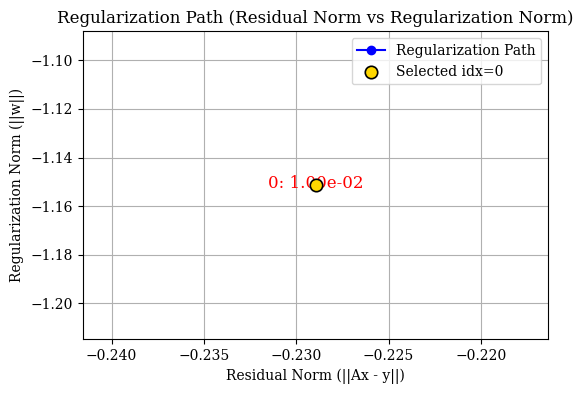

Training error at iteration 0 :
Generalization error at iteration 0 :


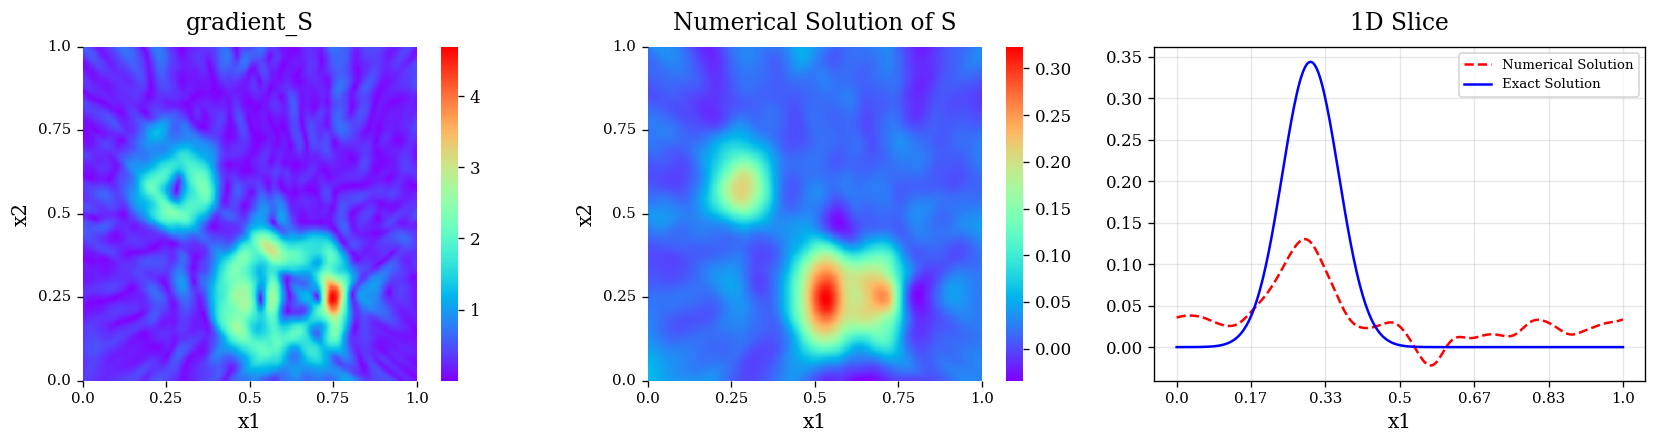

S_l_inf= 3.044484119262384 S_L_2= 0.2791810210597807 S_l_2= 0.835559807677556
Adaptive mesh refinement at iteration 0 ...
Generating visualizations...
1. Plotting mesh comparison...


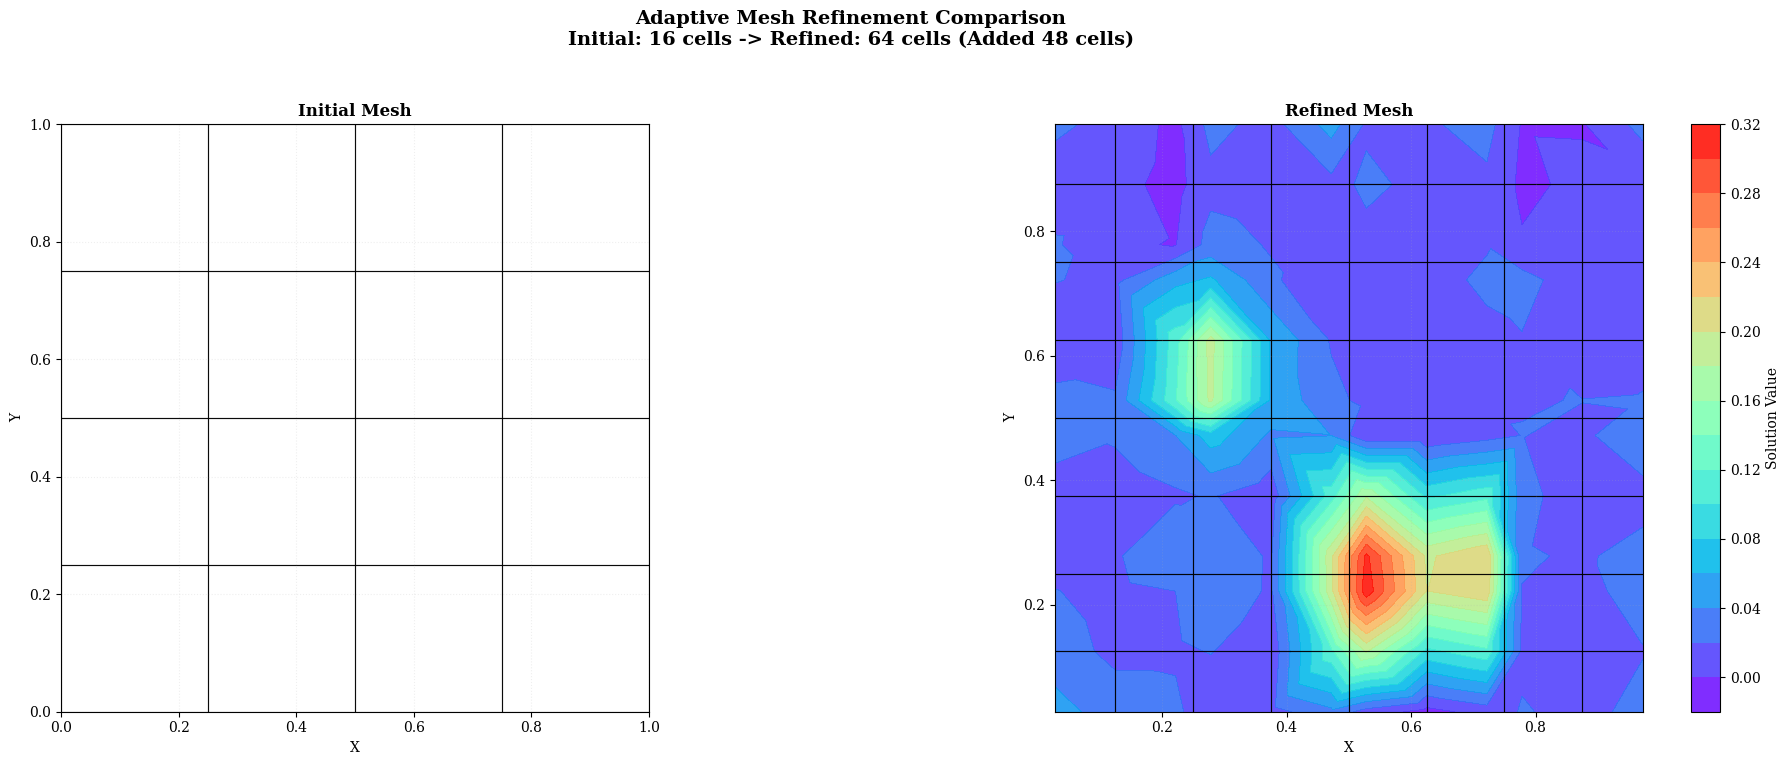

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


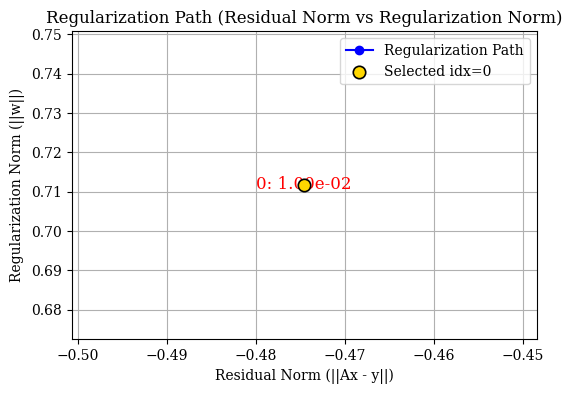

Training error at iteration 1 :
Generalization error at iteration 1 :


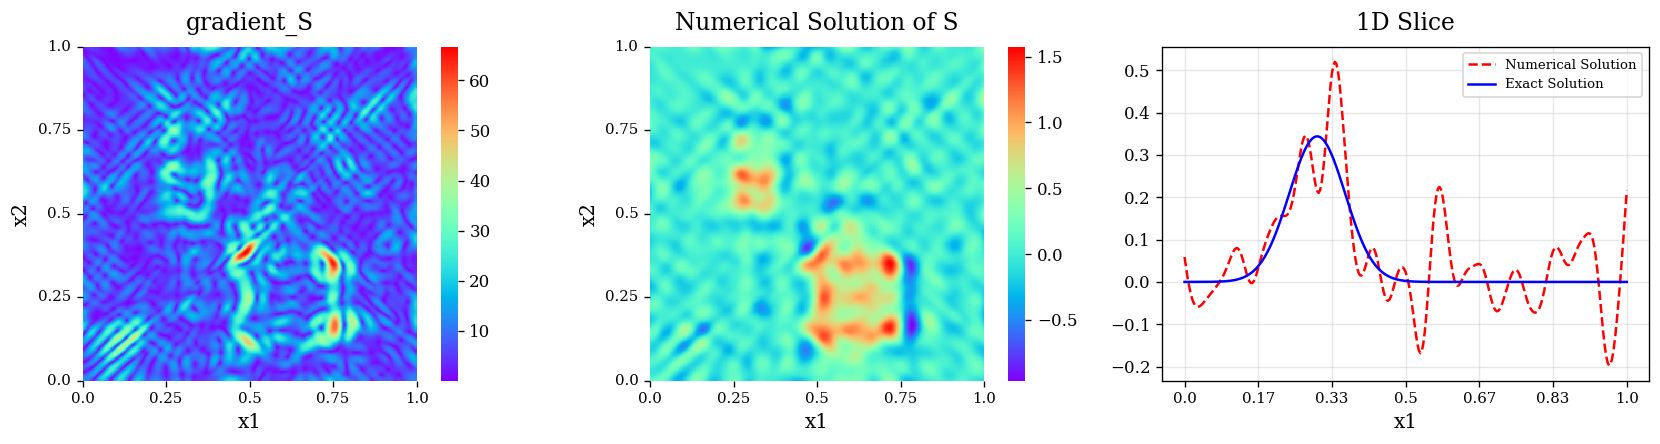

S_l_inf= 4.199598944285441 S_L_2= 0.19927162187697167 S_l_2= 0.5963992731993911
Adaptive mesh refinement at iteration 1 ...
Generating visualizations...
1. Plotting mesh comparison...


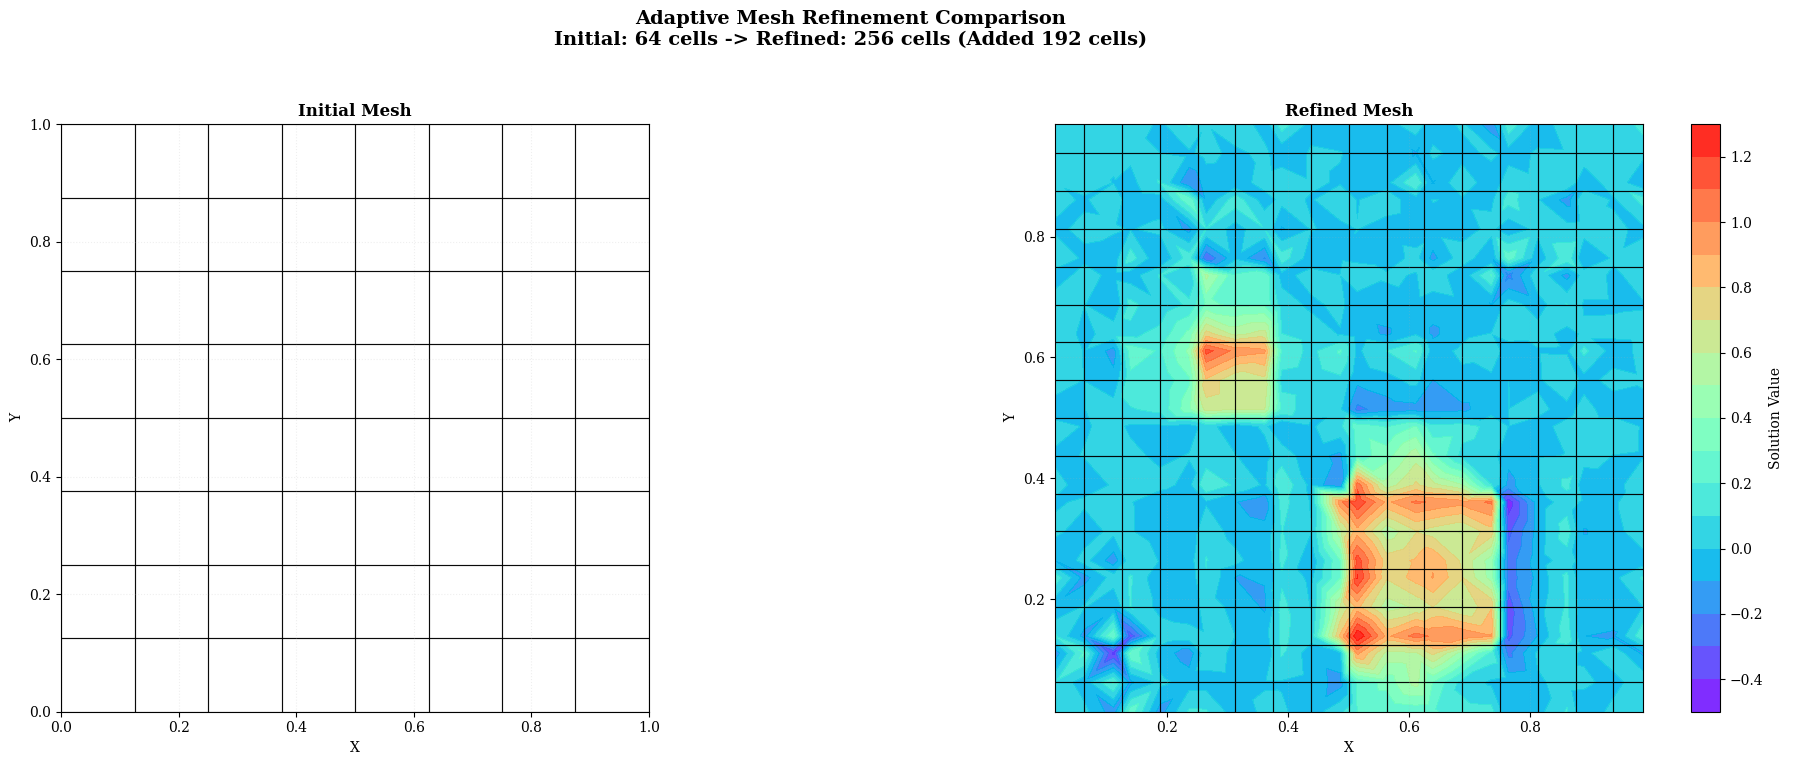

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


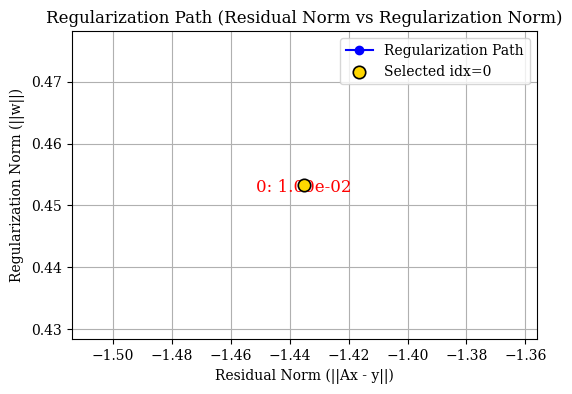

Training error at iteration 2 :
Generalization error at iteration 2 :


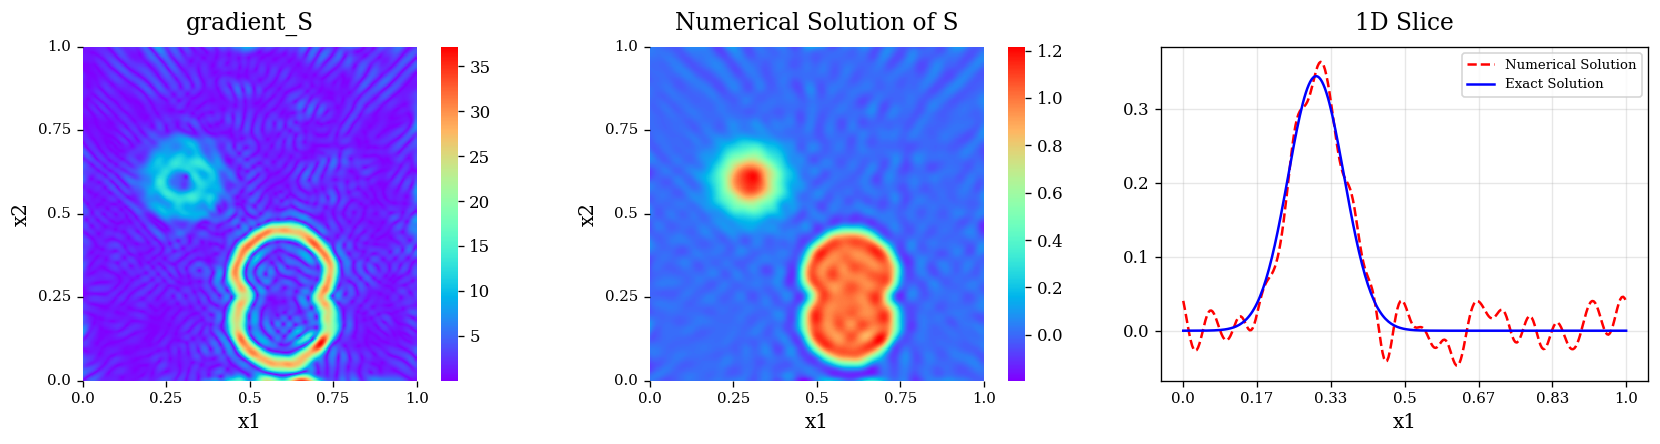

S_l_inf= 2.640225111343643 S_L_2= 0.06657500825158871 S_l_2= 0.19925208697806768
Adaptive mesh refinement at iteration 2 ...
Generating visualizations...
1. Plotting mesh comparison...


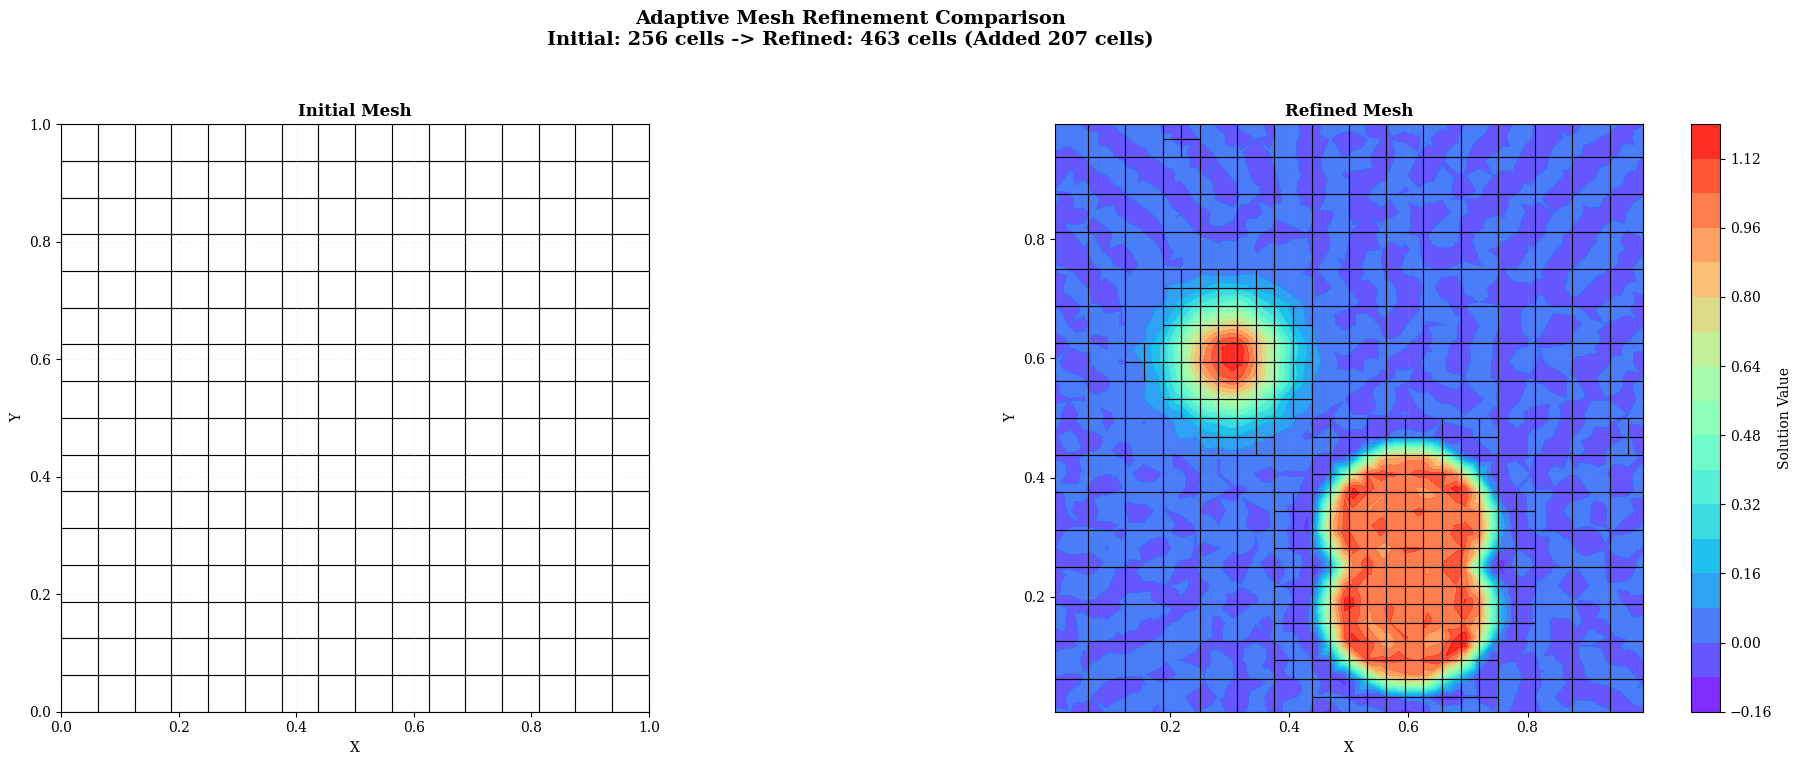

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


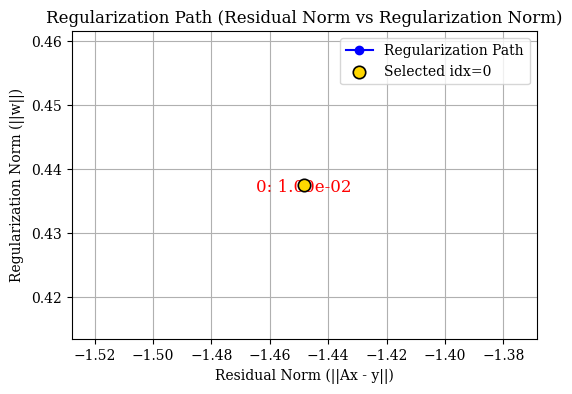

Training error at iteration 3 :
Generalization error at iteration 3 :


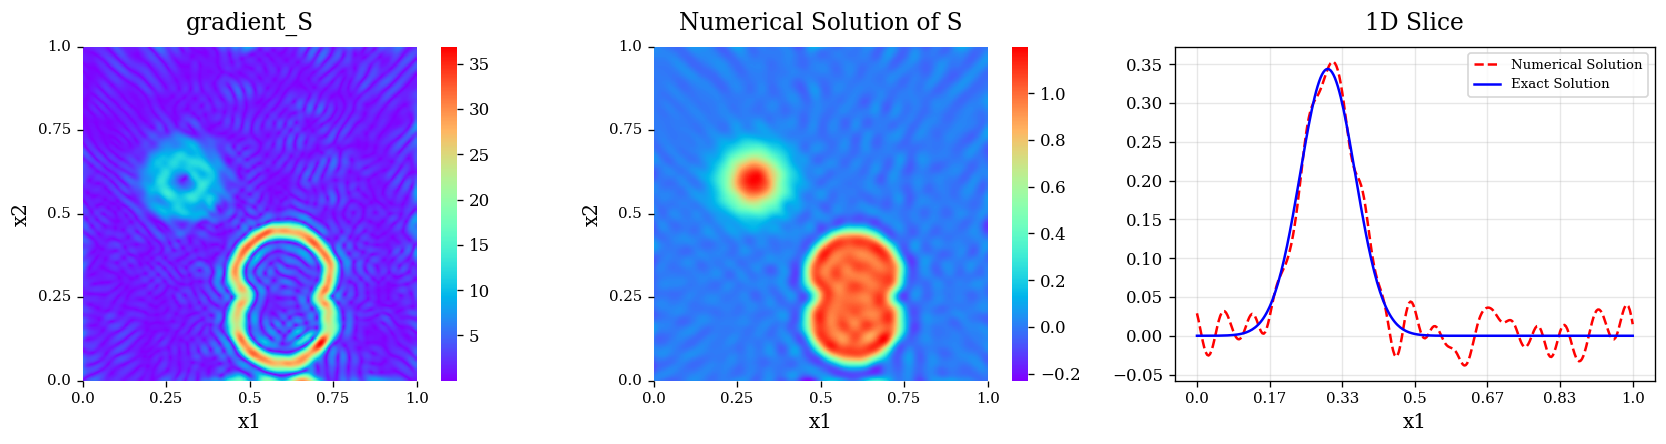

S_l_inf= 2.5833813591714123 S_L_2= 0.06596363517313396 S_l_2= 0.19742231083528503
Adaptive mesh refinement at iteration 3 ...
Generating visualizations...
1. Plotting mesh comparison...


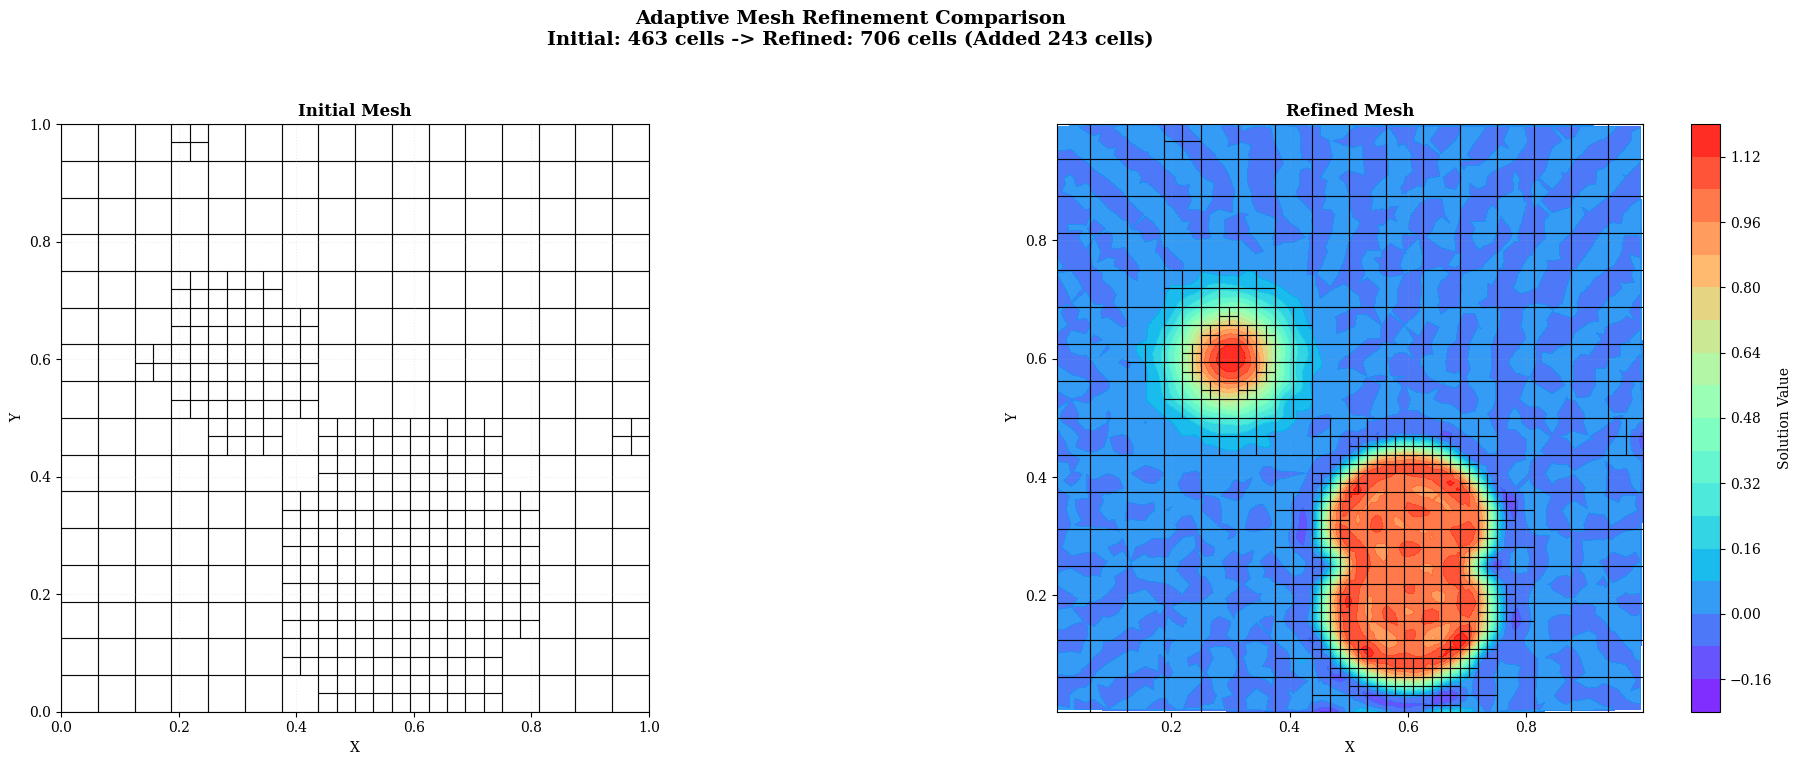

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


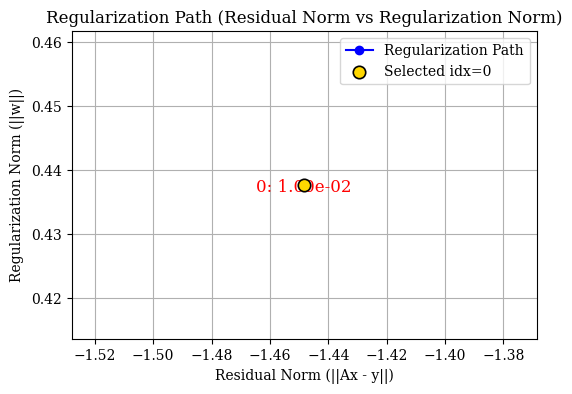

Training error at iteration 4 :
Generalization error at iteration 4 :


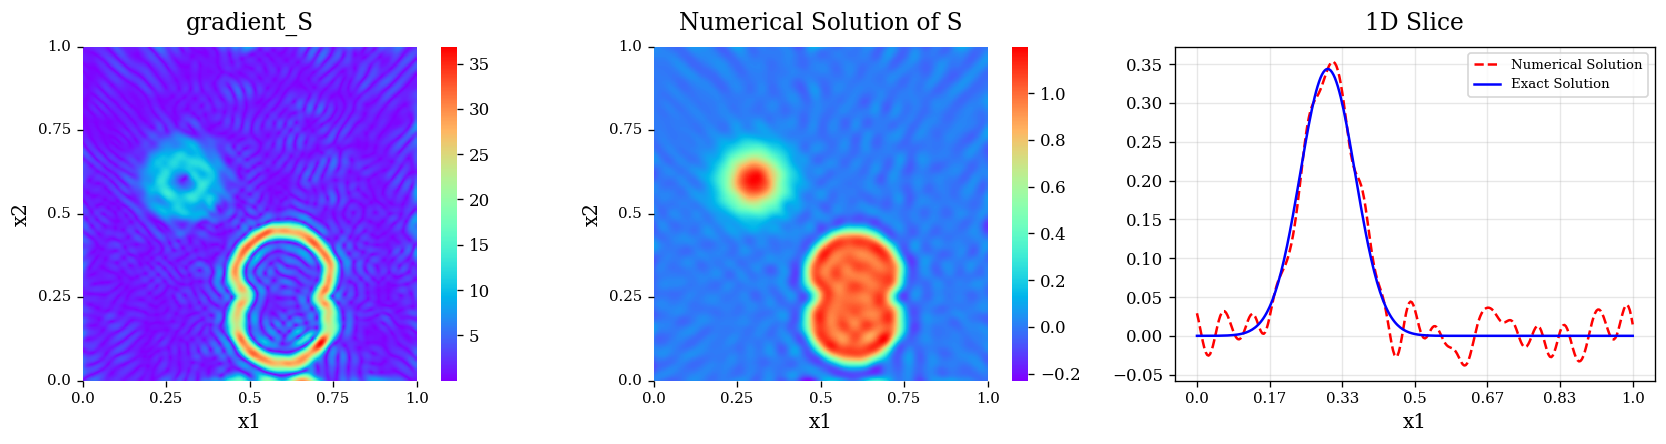

S_l_inf= 2.5836777270490163 S_L_2= 0.06596372771711599 S_l_2= 0.19742258780981406
Stop at iteration 4


In [5]:
iter_int= 5
Ix,Iy=4,4  # Number of grid cells in the x direction
delta=10**(-3)
nx=3
lamb_regu=np.logspace(-2,-1,1)
Qx,Qy=150,150
max_level=4
current_maxiter=1
af="Tanh"
Shape=[]
refine_threshold_S=1/100
refine_threshold_grad=1/300
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_l2,S_num_store=main.ada_int(iter_int,delta,cells,nx,model_tanh,M,af,Shape,[],kk,F,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,elegant_source,points_b,lamb_regu,Qx,Qy,device,cupy_device,refine_threshold_S,refine_threshold_grad,current_maxiter,max_level)


In [6]:
# Save cells_store
import pickle
import pickle
with open("./noise=5%/cells_store_last.pkl", "wb") as f:
    pickle.dump(cells_store[-1], f)

In [7]:
len(cells_store[-1])

706

In [8]:
np.save("./noise=5%/S_num_store_ada.npy",S_num_store)

In [9]:
np.save("./noise=5%/g_S.npy",g_S)

In [7]:
g_S=np.load("./noise=5%/g_S.npy")
S_num_store=np.load("./noise=5%/S_num_store_ada.npy")

DBSCAN eps = 0.016667 (5.000000 * h, h = 0.003333)
Number of detected clusters: 4
Number of retained clusters: 1
  CV of S_num (boundary_interior, n=10793): 0.419
Cluster 0: AR=1.33
  Res_Rect=0.069826 vs Res_Ellip=0.061324
  center=(0.6008, 0.2513)
  -> Decision: general (Sigmoid)


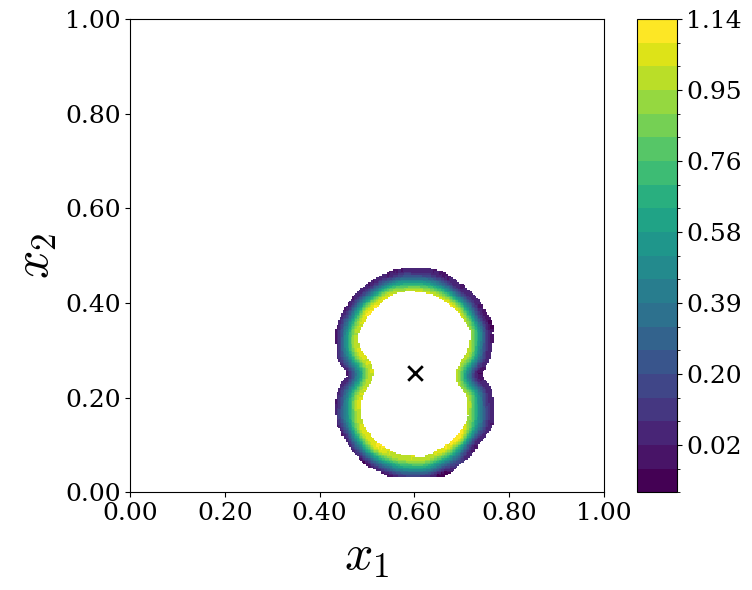

LaTeX table rows:
{\emph{Ex}} & Cluster $k$ & $\boldsymbol{c}_k$ & $r_k$ or $\boldsymbol{L}_k$ & $\mathcal{E}_{\mathrm{rect}}^{(k)}$ & $\mathcal{E}_{\mathrm{ellip}}^{(k)}$ & $\mathrm{AR}_k$ & $\mathrm{CV}_k$ & $\mathcal{T}_k$ & $\sigma_k$ \\
Ex 4.6 & 1 & (6.01e-01, 2.51e-01) & - & 0.0698 & 0.0613 & 1.33 & 0.419 & \textbf{general} & Sigmoid \\


['{\\emph{Ex}} & Cluster $k$ & $\\boldsymbol{c}_k$ & $r_k$ or $\\boldsymbol{L}_k$ & $\\mathcal{E}_{\\mathrm{rect}}^{(k)}$ & $\\mathcal{E}_{\\mathrm{ellip}}^{(k)}$ & $\\mathrm{AR}_k$ & $\\mathrm{CV}_k$ & $\\mathcal{T}_k$ & $\\sigma_k$ \\\\',
 'Ex 4.6 & 1 & (6.01e-01, 2.51e-01) & - & 0.0698 & 0.0613 & 1.33 & 0.419 & \\textbf{general} & Sigmoid \\\\']

In [8]:
from importlib import reload
import bound_detect
reload(bound_detect)
x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)
eps_cluster=5
mini_samples=20
para_abs=100
para_grad=3
results=bound_detect.detect_shape(
    g_S, X.T, Y.T,
    tau_x_min, tau_x_max, tau_y_min, tau_y_max,
    para_abs, para_grad, eps_cluster, mini_samples,
    S_num_store[-1],
    output_directory="./noise=5%",
    output_filename="plot.png",
    min_cluster_size=200,
    keep_top_k=None,
)
print("LaTeX table rows:")
bound_detect.print_latex_result_rows(results, example_name="Ex 4.6", include_header=True)


In [11]:
results

[{'cluster_id': 0,
  'shape': 'general',
  'params': {'center': array([0.60078789, 0.25131872])},
  'profile': 'Sigmoid',
  'boundary_points': array([[0.5463    , 0.0342    ],
         [0.54566667, 0.03483333],
         [0.54503333, 0.03483333],
         ...,
         [0.5482    , 0.0342    ],
         [0.54756667, 0.0342    ],
         [0.54693333, 0.0342    ]]),
  'diagnostics': {'Lx': 0.3266666666666667,
   'Ly': 0.43333333333333335,
   'aspect_ratio': 1.3265306122448979,
   'res_rect': 0.06982645307031739,
   'res_ellip': 0.061323642101356525,
   'residual_threshold': 0.05,
   'tori_ratio': 0.4077683949561109,
   'r_mean': 0.17217805047140278,
   'min_dist_to_center': 0.09079746789106131,
   'max_dist_to_center': 0.22266921373549334,
   'dist_05': 0.1159726630666288,
   'dist_95': 0.21145016606355538},
  'aspect_ratio': 1.3265306122448979,
  'res_rect': 0.06982645307031739,
  'res_ellip': 0.061323642101356525,
  'Lx': 0.3266666666666667,
  'Ly': 0.43333333333333335,
  'tori_ratio':

In [12]:
import bound_detect
reload(bound_detect)
if not results:
    raise RuntimeError("detect_shape returned no clusters; cannot extract kidney boundary.")

kidney_result = results[0]
kidney_bound = np.asarray(kidney_result["boundary_points"])
print("Selected kidney cluster:", kidney_result["cluster_id"], kidney_result["shape"], kidney_result["params"].get("center"))


Selected kidney cluster: 0 general [0.60078789 0.25131872]


In [13]:
# kidney_bound is already the ordered boundary extracted inside detect_shape(...).
kidney_bound = np.asarray(kidney_bound)


In [14]:
np.save("./noise=5%/kidney_num.npy",kidney_bound)

In [15]:
# 2. Set parameters and extract the true kidney boundary from the implicit function
func_params = {'h': 0.6, 'k': 0.25, 'a': a}
contour_points_implicit = bound_detect.get_contour_points_from_implicit(
    kidney_curve,
    func_args=func_params,
    x_range=(tau_x_min, tau_x_max),
    y_range=(tau_y_min, tau_y_max)
)


/data1/hxw-b25/MA-RFM/Ex4.6/../main_code/2d/bound_detect.py:109: RuntimeWarning: overflow encountered in exp
  z_flat = 1 / (1 + np.exp(K * signed_distances)) # Sigmoid映射生成平滑边界值


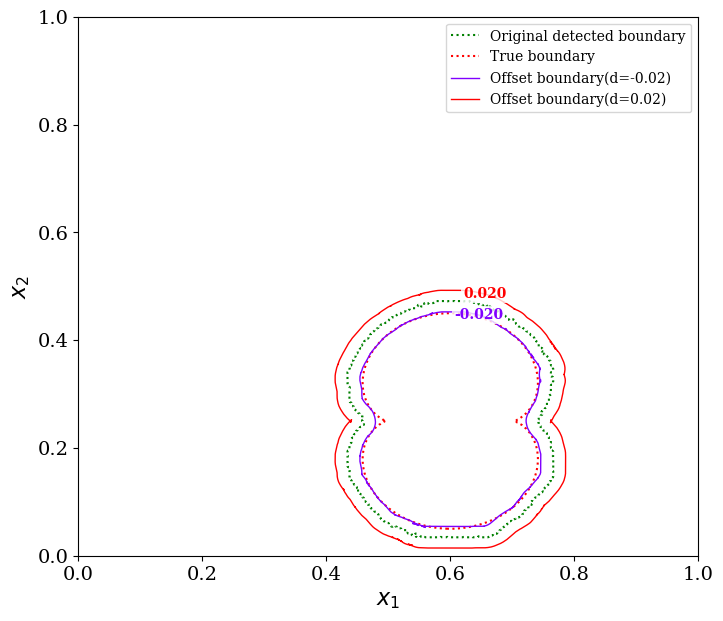

In [16]:
import numpy as np
reload(bound_detect)
# 4. Offset the smoothed boundary.
offset_distances = np.linspace(-0.02,0.02
                               ,2)


kidney_boundary=kidney_bound
alpha=5*10**(-3)

try:
    kidney_center = np.asarray(kidney_result["params"]["center"])
except NameError:
    kidney_center = np.mean(kidney_boundary, axis=0)

contour_points_scaled = bound_detect.center_oriented_offset_batch(kidney_boundary, kidney_center, offset_distances, n_resample=1200)

# 5. Generate 2D grid points for visualization.
x = np.linspace(0, 1, 150)
y = np.linspace(0, 1, 150)
X, Y = np.meshgrid(x, y)

# 6. Compute soft-boundary values using the final offset boundary points.
Z = bound_detect.generate_soft_boundary(X, Y, contour_points_implicit, K=2000)

# 8. Draw a 2D contour plot for comparison.
plt.figure(figsize=(8, 7))

# Plot comparison boundaries.
plt.plot(kidney_boundary[:, 0], kidney_boundary[:, 1], c='g', linestyle=':', label='Original detected boundary')
plt.plot(contour_points_implicit[:, 0], contour_points_implicit[:, 1], c='r', linestyle=':', label='True boundary')
colors = plt.cm.rainbow(np.linspace(0, 1, len(offset_distances)))
for i, d in enumerate(offset_distances):
    plt.plot(contour_points_scaled[i,:, 0], contour_points_scaled[i,:, 1], color=colors[i], linewidth=1, label=f'Offset boundary(d={d})')
    if abs(d) > 1e-6:
        # Choose different positions to avoid overlapping labels.
        # For example, use one-quarter of the curve for positive offsets and three-quarters for negative offsets.
        if d > 0:
            label_position_index = len(contour_points_scaled[1]) // 2
        else:
            label_position_index = ( len(contour_points_scaled[1])) // 2
            
        point_for_label = contour_points_scaled[i,label_position_index,:]
        
        plt.text(
            x=point_for_label[0],
            y=point_for_label[1],
            s=f'{d:.3f}',
            color=colors[i],
            fontweight='bold',
            fontsize=10,
            ha='center',
            va='center',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1.5)
        )
#plt.title('Boundary Smoothing and Offsetting Comparison')
plt.xlabel('$x_1$',fontsize=16)
plt.ylabel('$x_2$',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.savefig("./noise=5%/scale.png", dpi=300, bbox_inches='tight')
plt.show()


In [17]:
M_sig=1600
kidney_boundary = kidney_bound
alpha = 5e-3

# Offset the numerically detected boundary by several detection-grid spacings.
h = max((tau_x_max - tau_x_min) / (2*Qx), (tau_y_max - tau_y_min) / (2*Qy))
scale_factor = np.random.uniform(-10*h, 0, size=M_sig)
try:
    kidney_center = np.asarray(kidney_result["params"]["center"])
except Exception:
    kidney_center = np.mean(kidney_boundary, axis=0)

scale_curves, sign_distances_t = bound_detect.generate_signed_distance(
    g_store[-1],
    kidney_boundary,
    alpha,
    scale_factor,
    M_sig,
    center=kidney_center,
    center_oriented=True,
)


In [18]:
scale_factor

array([-0.01659899, -0.01470712, -0.00482378, ..., -0.00521367,
       -0.01144807, -0.00197186])

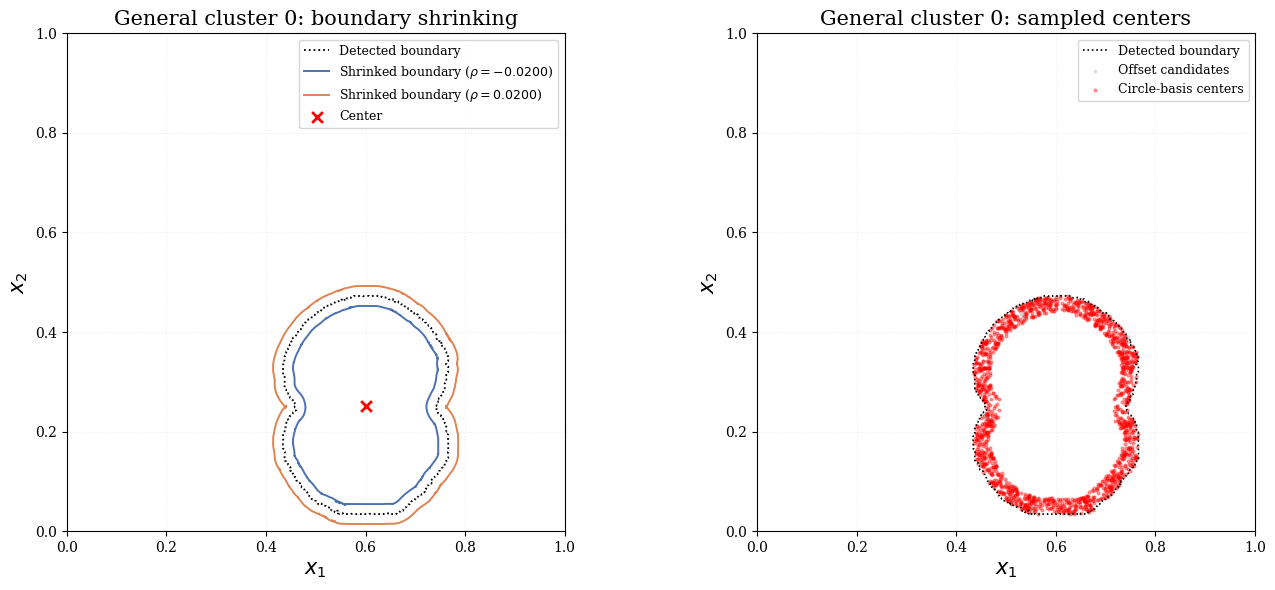

In [19]:
reload(visual)
reload(bound_detect)

try:
    kidney_center = np.asarray(kidney_result["params"]["center"])
except Exception:
    kidney_center = np.mean(kidney_boundary, axis=0)

kidney_cluster_id = int(kidney_result.get("cluster_id", 0)) if isinstance(kidney_result, dict) else 0
kidney_item = dict(kidney_result) if isinstance(kidney_result, dict) else {"cluster_id": kidney_cluster_id}
kidney_item["cluster_id"] = kidney_cluster_id
kidney_params = dict(kidney_item.get("params", {}))
kidney_params["center"] = kidney_center
kidney_item["params"] = kidney_params

kidney_noise_outputs = visual.plot_boundary_shrinking_and_noise_centers(
    [kidney_item],
    boundaries={kidney_cluster_id: kidney_boundary},
    g_S=g_S,
    tau_x_min=tau_x_min,
    tau_x_max=tau_x_max,
    tau_y_min=tau_y_min,
    tau_y_max=tau_y_max,
    h=h,
    alpha=alpha,
    M_sig=M_sig,
    shrink_distances=globals().get("offset_distances", np.array([-6 * h, -3 * h])),
    noise_scale_range=(-10.0, 0.0),
    n_resample_shrink=1200,
    n_resample_noise=800,
    output_directory="./noise=5%",
    output_filename="circle_basis_centers.png",
)

offset_curves = kidney_noise_outputs["offset_curves"][kidney_cluster_id]
candidate_centers = kidney_noise_outputs["candidate_centers_by_cluster"][kidney_cluster_id]
scale_factor_noise = kidney_noise_outputs["noise_scale_factors_by_cluster"][kidney_cluster_id]
noise_centers = kidney_noise_outputs["noise_centers_by_cluster"][kidney_cluster_id]
b1_noise = noise_centers[:, 0]
b2_noise = noise_centers[:, 1]
bound_num_scaled = noise_centers.reshape(1, -1, 2)

In [20]:
K_min=1000
K_max=30000
modelsig = net_2d.local_rep(in_features=2, out_features=1, hidden_layers=1, M=M_sig, M_noise=[],b1_noise=[],b2_noise=[],x_max=1, x_min=0, y_max=1, y_min=0, r_min=[], r_max=[],b1_min=[],b1_max=[],b2_min=[],b2_max=[],width_min=[],width_max=[],height_min=[],height_max=[],peak_min=[],peak_max=[],v_min=[],v_max=[],K_min=K_min,K_max=K_max,R_m_for_init=R_m,af="sigmoid",Shape="general",device=device).to(device)
modelnoise = net_2d.local_rep(in_features=2, out_features=1, hidden_layers=1, M=1, M_noise=b1_noise.shape[0],b1_noise=-b1_noise,b2_noise=-b2_noise,x_max=1, x_min=0, y_max=1, y_min=0, r_min=0, r_max=10*h,b1_min=0,b1_max=1,b2_min=0,b2_max=1,width_min=[],width_max=[],height_min=[],height_max=[],peak_min=[],peak_max=[],v_min=[],v_max=[],K_min=K_min,K_max=K_max,R_m_for_init=R_m,af="sigmoid",Shape="noise",device=device).to(device)


In [21]:
sum_mat,all_g_p1,all_g_n,cells_copy1=matrix_assemble.mat_assemble2(cells_store[-1],model_tanh,modelsig,modelnoise,[],"mix","general","noise",sign_distances_t,kk,0,points_b,device,cupy_device)

/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


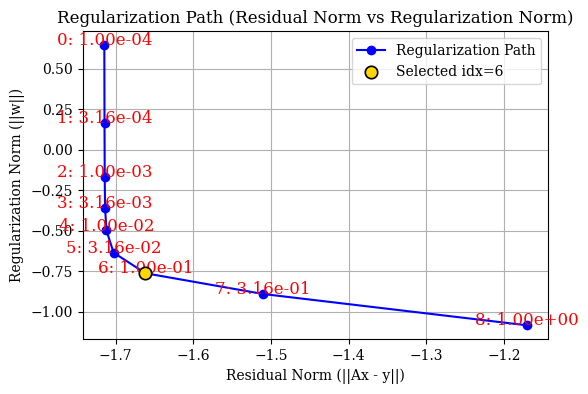

In [22]:
lamb_regu=np.logspace(-4,0,9,endpoint=True)
res,reg_norm,w_store=inverse_solver.L_curve(sum_mat,F,[],[],[],lamb_regu,"linear",device,cupy_device) # Solve first for q

In [23]:
sample_s=error_general_2d.test_p(Qx,Qy,tau_x_min,tau_x_max,tau_y_min,tau_y_max)
_,sign_distances_test=bound_detect.generate_signed_distance(
    sample_s,
    kidney_bound,
    alpha,
    scale_factor,
    M_sig,
    center=kidney_center,
    center_oriented=True,
)


L-curve corner index: 6
Curvature-centered lambda window:
  idx=5, lambda=3.162278e-02, curvature=1.092490e+00
  idx=6, lambda=1.000000e-01, curvature=1.350917e+00 <== center
  idx=7, lambda=3.162278e-01, curvature=2.586925e-01
candidate idx: [5 6 7]
candidate lambda: [0.03162278 0.1        0.31622777]


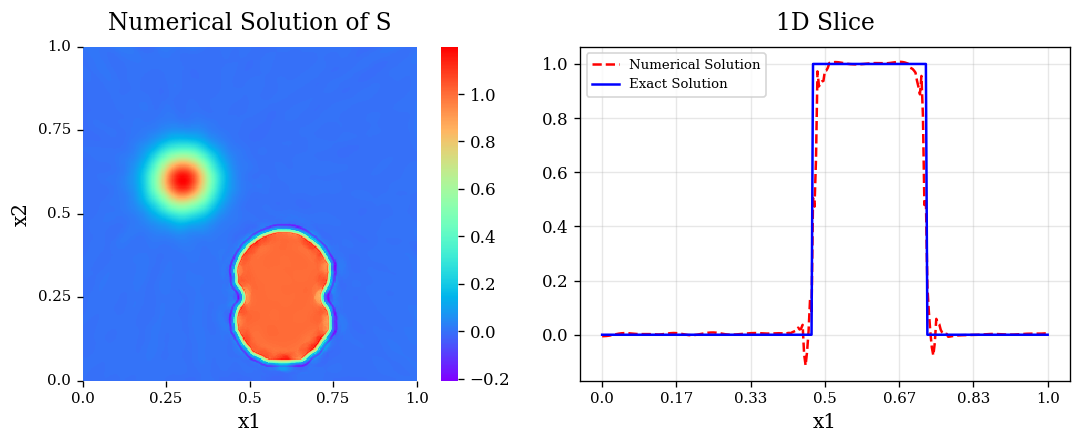

S_l_inf= 2.8331225367800315 S_L_2= 0.04656446163680743 S_l_2= 0.13936259872596624
candidate idx=5, lamb=0.0009999999999999998, S_l_inf=2.8331225367800315, S_l_2=0.13936259872596624


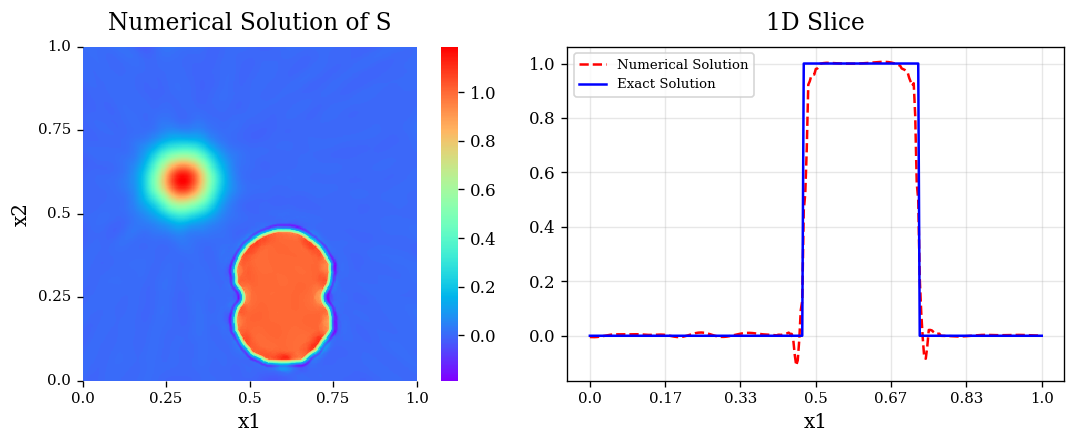

S_l_inf= 2.852999254349177 S_L_2= 0.0456573440470656 S_l_2= 0.1366476899691016
candidate idx=6, lamb=0.010000000000000002, S_l_inf=2.852999254349177, S_l_2=0.1366476899691016


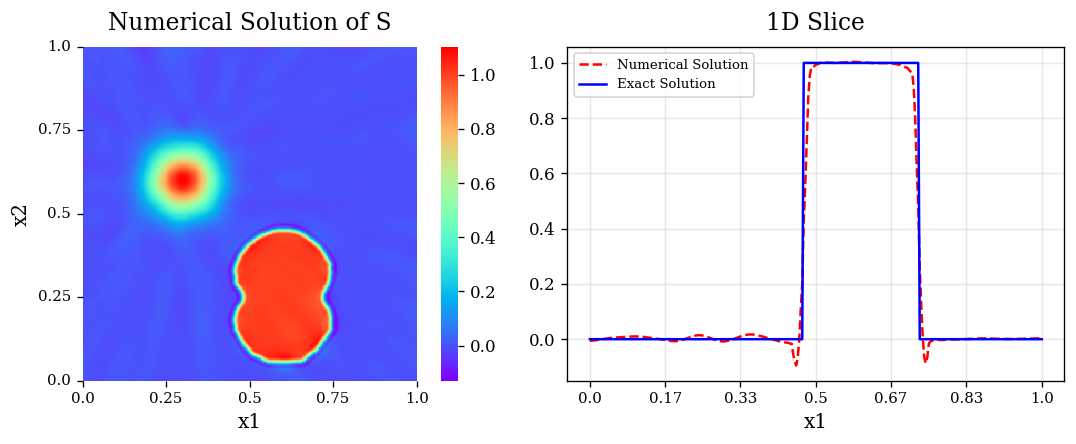

S_l_inf= 2.9458851511608013 S_L_2= 0.04752001947475102 S_l_2= 0.1422224841159762
candidate idx=7, lamb=0.1, S_l_inf=2.9458851511608013, S_l_2=0.1422224841159762
picked idx: 5
lamb: 0.0009999999999999998


In [24]:
reload(inverse_solver)
window_idx, window_lambda, window_w, curvature = inverse_solver.lambda_window_by_curvature(
    lamb_regu, res, reg_norm, radius=1, w_store=w_store
)
print('candidate idx:', window_idx)
print('candidate lambda:', window_lambda)
window_results = []
for local_i, cand_idx in enumerate(window_idx):
    cand_lamb = window_lambda[local_i]**2
    cand_w = window_w[:, local_i]
    
    result_tuple = error_general_2d.test(model_tanh,modelsig,modelnoise,[],sample_s,cand_w,"mix","general","noise",sign_distances_test,True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,elegant_source,0.27,0,device)
    window_results.append({
        'idx': int(cand_idx),
        'lambda': cand_lamb,
        'w': cand_w,
        'result': result_tuple,
    })
    print(
        f"candidate idx={int(cand_idx)}, lamb={cand_lamb}, "
        f"S_l_inf={result_tuple[2]}, S_l_2={result_tuple[3]}"
    )
pick = 0
picked = window_results[pick]
idx = picked['idx']
lamb = picked['lambda']
picked_w = picked['w']
S_test_num,S_test_true,S_l_inf1,S_l_21,g_SS=picked['result']
print('picked idx:', idx)
print('lamb:', lamb)


In [25]:
import pickle

with open("./noise=5%/cells_store_last.pkl", "wb") as f:
    pickle.dump(cells_store[-1], f)

In [26]:
np.save("./noise=5%/sign_distances_test.npy", sign_distances_test)
np.save("./noise=5%/sign_distances_train.npy", sign_distances_t)

In [27]:
np.save("./noise=5%/sign_distances_test.npy", sign_distances_test)
np.save("./noise=5%/w_store.npy", w_store)

In [28]:
np.save("./noise=5%/S_test_num.npy",S_test_num)
np.save("./noise=5%/S_test_true.npy",S_test_true)
np.save("./noise=5%/g_SS.npy",g_SS)

In [29]:
torch.save(model_tanh.state_dict(), "./noise=5%/model_tanh.pth")
torch.save(modelsig.state_dict(), "./noise=5%/model_sig.pth")
torch.save(modelnoise.state_dict(), "./noise=5%/model_noise.pth")

In [30]:
g_S=np.load("./noise=5%/g_S.npy",allow_pickle=True)
S_num_store=np.load("./noise=5%/S_num_store_ada.npy",allow_pickle=True)

In [31]:
n_integral=len(cells_store[-1])*9
print('n_integral:',n_integral)
print('S_l2[-1]:',S_l2[-1])
print('lamb_regu:',lamb)
print('S_l21:',S_l_21)

n_integral: 6354
S_l2[-1]: 0.19742258780981406
lamb_regu: 0.0009999999999999998
S_l21: 0.13936259872596624
